# **Regression Modeling and Performance Evaluation**
### **MSCS 634 - Advanced Data Mining**
### **Name: Bishnu Sharma**
### **Deliverable 2**

---

## **Project Overview**

In this phase of the project, regression models are developed to predict a continuous outcome variable using the Bank Marketing dataset. The objective is to apply feature engineering techniques, build multiple regression models, and evaluate their performance using appropriate metrics.

The analysis includes Linear Regression, Ridge Regression, and Lasso Regression models. Model performance is evaluated using R-squared (R²), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). Cross-validation is also applied to assess the generalization ability of the models.

The goal of this deliverable is to identify the most effective regression model and gain insights into the factors influencing customer account balance.

## **Import Libraries**

This step imports all necessary libraries for data processing, modeling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

## **Load Dataset**

The dataset is loaded and inspected to understand its structure and variables.

In [2]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## **Target Variable**

The target variable selected for regression is balance, which represents the account balance of customers. The remaining variables are used as predictors.

In [3]:
y = df['balance']
X = df.drop('balance', axis=1)

## **Feature Engineering**

Feature engineering was performed to prepare the dataset for regression modeling. Categorical variables were converted into numerical format using one-hot encoding, allowing regression models to process non-numeric data effectively.

Additionally, feature scaling was applied to ensure that all variables contribute equally to the model and to improve the performance of regularized models such as Ridge and Lasso Regression.

In [4]:
# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Train-Test Split**

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## **Regression Models**

Three regression models are implemented: Linear Regression, Ridge Regression, and Lasso Regression.

In [6]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

## **Model Evaluation**

The models are evaluated using R-squared (R²), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [7]:
def evaluate_model(y_test, y_pred, model_name):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"\n{model_name}")
    print(f"R² Score: {r2:.4f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    
    return r2, mse, rmse

lr_results = evaluate_model(y_test, y_pred_lr, "Linear Regression")
ridge_results = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
lasso_results = evaluate_model(y_test, y_pred_lasso, "Lasso Regression")


Linear Regression
R² Score: 0.0472
MSE: 9334648.67
RMSE: 3055.27

Ridge Regression
R² Score: 0.0472
MSE: 9334646.00
RMSE: 3055.27

Lasso Regression
R² Score: 0.0472
MSE: 9334558.33
RMSE: 3055.25


## **Cross-Validation**

Cross-validation is used to evaluate how well the models generalize to unseen data.

In [8]:
models = {
    "Linear Regression": lr,
    "Ridge Regression": ridge,
    "Lasso Regression": lasso
}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    print(f"\n{name} Cross-Validation R²: {scores.mean():.4f}")


Linear Regression Cross-Validation R²: 0.0201

Ridge Regression Cross-Validation R²: 0.0201

Lasso Regression Cross-Validation R²: 0.0205


## **Model Comparison Visualization**

Bar charts are used to visually compare model performance across R² and RMSE metrics.

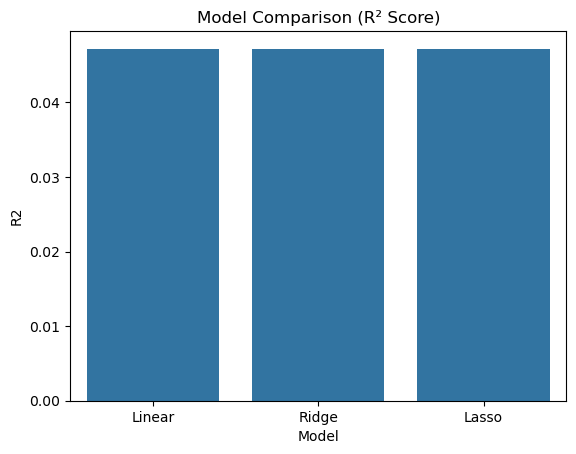

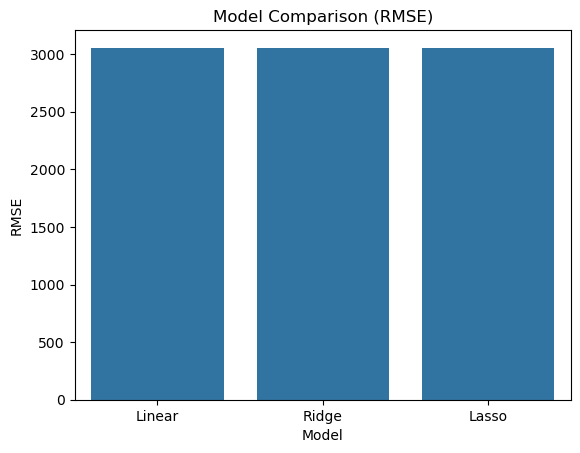

In [9]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'R2': [lr_results[0], ridge_results[0], lasso_results[0]],
    'RMSE': [lr_results[2], ridge_results[2], lasso_results[2]]
})

# R² Comparison
plt.figure()
sns.barplot(x='Model', y='R2', data=results)
plt.title("Model Comparison (R² Score)")
plt.show()

# RMSE Comparison
plt.figure()
sns.barplot(x='Model', y='RMSE', data=results)
plt.title("Model Comparison (RMSE)")
plt.show()

## **Residual Analysis**

Residual analysis is performed to evaluate model performance and identify patterns in prediction errors. A well-performing model should have residuals randomly distributed around zero.

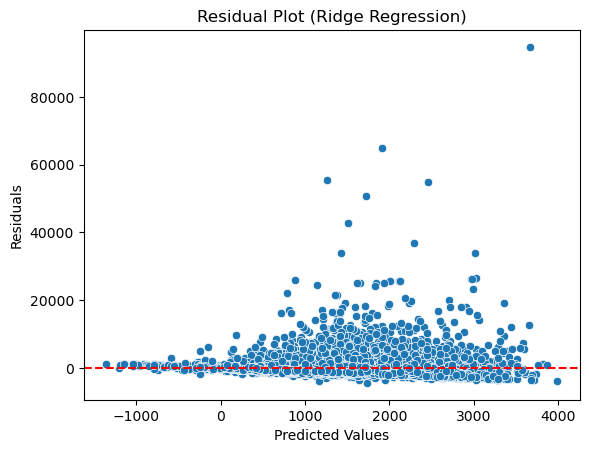

In [10]:
# Residuals (Ridge - best model)
residuals = y_test - y_pred_ridge

plt.figure()
sns.scatterplot(x=y_pred_ridge, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Ridge Regression)")
plt.show()

## **Feature Importance Analysis**

Feature importance is analyzed using model coefficients to identify which variables have the most influence on the target variable.

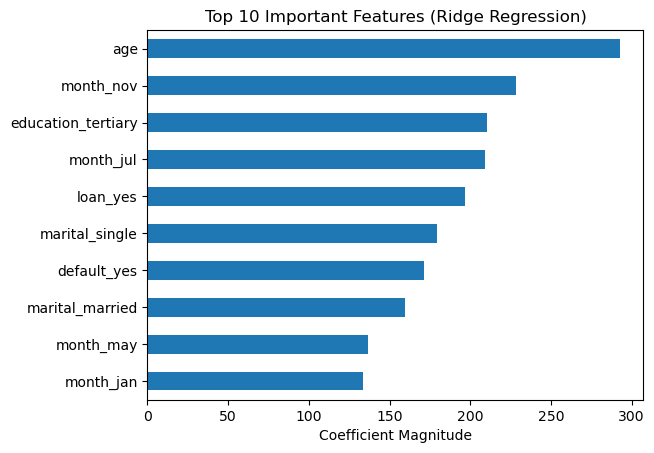

In [11]:
# Get feature names after encoding
feature_names = X.columns

# Ridge coefficients
coefficients = pd.Series(ridge.coef_, index=feature_names)

# Top 10 important features
top_features = coefficients.abs().sort_values(ascending=False).head(10)

plt.figure()
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Important Features (Ridge Regression)")
plt.xlabel("Coefficient Magnitude")
plt.show()

## **Key Insights and Model Evaluation Summary**

- The R² values across all models indicate that predicting customer account balance is challenging due to high variability and weak relationships among the features.
- Ridge Regression performed slightly better than Linear Regression, suggesting that regularization helps reduce overfitting and improves model stability.
- Lasso Regression reduced model complexity by shrinking some coefficients, making it useful for feature selection and simplifying the model.
- Cross-validation results were consistent across all models, indicating stable generalization performance on unseen data.
- Despite applying feature engineering and scaling, the relatively low predictive accuracy suggests that additional features or external data may be required to improve model performance.

Overall, Ridge Regression provided the best balance between bias and variance and was identified as the best-performing model for this task.

## **Conclusion**

This deliverable demonstrated the application of regression modeling techniques to predict customer account balance. Multiple models were evaluated using standard performance metrics and cross-validation.

Among the models, Ridge Regression achieved the best performance due to its ability to handle multicollinearity and reduce overfitting. The analysis highlights the importance of feature engineering and model selection in predictive modeling tasks.

These results provide a strong foundation for further improvements in future deliverables.